# Bike Rentals: Modeling

## Objective

---

Задача: **предсказать общий почасовой спрос** — сколько велосипедов арендуют во всём городе
в данный час (сумма по всем киоскам). Гранулярность — **количество за час по всему городу**, без разреза по локациям.

Ноутбук читает датасет week-2 (`hourly_by_location.csv`, грануляция `(hour, location)`) и
**агрегирует его до `(hour)`** — целевой формы для этой задачи.

**Структура анализа — 1 основной + 3 уточняющих.** Разведка фич вынесена в ноутбуки-спутники ([exploration_holidays](exploration_holidays.ipynb), [exploration_weather](exploration_weather.ipynb), [exploration_time_trends](exploration_time_trends.ipynb)); здесь — сводка их выводов (ниже) и моделирование. Поэтому в этом ноутбуке:

1. EDA таргета (распределение, скошенность)
2. Baseline-регрессия
3. Итеративное улучшение (feature engineering, выбор модели)
4. Выводы для интеграции в пайплайн

## Imports & Setup

---

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

## Load week-2 dataset

In [2]:
DATA_PROCESSED = Path("../data/processed")

dataset = pd.read_csv(DATA_PROCESSED / "hourly_by_location.csv", parse_dates=["datetime_hourly"])

assert dataset.notna().all().all(), "unexpected NaN in hourly_by_location!"
print(f"Shape: {dataset.shape}")
dataset.head()

Shape: (364959, 16)


,datetime_hourly,location_id,registered_rentals,direct_pickups,total_rentals,month,hour_of_day,day_of_week,is_weekend,days_since_launch,conditions,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,is_holiday
0,2011-01-01,0,0,0,0,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0
1,2011-01-01,1,0,0,0,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0
2,2011-01-01,2,0,1,1,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0
3,2011-01-01,3,1,0,1,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0
4,2011-01-01,4,2,0,2,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0


## Что показала разведка и какие фичи берём

---

*Разведка фич вынесена в 3 ноутбука-спутника; ниже — сводка их выводов.*

### Задача и таргет

**Гранулярность — почасовой тотал по городу.** Предсказываем сумму аренд по всему городу в час (`total_rentals` после агрегации по локациям), без разреза по киоскам.

### Разведка фич — 3 ноутбука

**Рост сервиса и временной тренд** | [exploration_time_trends.ipynb](exploration_time_trends.ipynb)
- Headline-рост +65% год к году, но **двухрежимный**: фаза запуска (≈ янв–апр 2011) и органический режим (с мая 2011, ~+52%).
- Фича тренда — **`days_since_launch`** (дни с 2011-01-01), а не `year`: ловит и межгодовой сдвиг, и внутригодовую рампу 2011-го. За 2013+ не экстраполирует (у деревьев — стена).
- Фаза запуска — разовый артефакт; дропать ли её строки из обучения — решаем экспериментом, не вслепую.

**Праздники** | [exploration_holidays.ipynb](exploration_holidays.ipynb)
- Бинарный `is_holiday` не различает зимние (спрос падает) и летние (растёт) праздники. Разброс велик.
- Группировка праздников бесполезна: 1–2 наблюдения на группу. Температура разброс не объясняет (проверено и отвергнуто).
- Рекомендация: три **раздельные** фичи `is_holiday`, `days_since_launch`, `month` (не новый агрегат) — дерево само ловит их взаимодействие на сплитах («праздник в декабре ≠ в июле»).

**Погода** | [exploration_weather.ipynb](exploration_weather.ipynb)
- Температура ↔ спрос ~линейна (монотонный рост, без разворота) — baseline ловит.
- `perceived_temperature_c` corr 0.99 с `temperature_c`, но ablation #5 говорит **оставить** (у HGB удаление роняет R² 0.892→0.879).
- Осадки давят спрос (`дождь × час`), но поверх часа добавляют мало (#2, +0.002 R²); влажность — слабый минус, ветер ≈0.
- `conditions` — ординал 0..3 (`heavy_rain` всего 3 часа). Сенсорные сбои (нули humidity, разрыв `perceived`↔`temperature`) поправлены в week-2 `weather_split`.

### Признаки и представление

**Временные признаки**
- `month`, `hour_of_day`, `day_of_week`, `is_weekend` — raw integers.
- Для линейных моделей нужно cyclic (sin/cos) для `hour_of_day`, `month`, `day_of_week` — иначе 23:00 и 00:00 «далеко».
- Для деревьев raw integers работают — cyclic не нужен.
- **`days_since_launch`** — тренд-фича.

**Лаги и агрегаты по спросу — осознанно вне scope.**
- Лаговые / rolling-фичи (спрос за прошлые часы/дни, скользящее среднее) сильны, но критерий отбора для прогноза наперёд — **можно ли подать обоснованное значение фичи на момент прогноза**. Для произвольной будущей даты у лагов такого значения нет: данных за «вчера» ещё не существует, подставить выдуманное = обмануть модель. → не берём; они для другой постановки (nowcast на ближайший час, где недавний факт доступен).
- Контраст — **погода проходит критерий**: значение подать можем (многолетняя история + погоду на дату прогнозируют с высокой вероятностью). На дальнем горизонте это всё же прогноз, не факт — небольшую ошибку вносит, но фича остаётся подаваемой и оправданной.

## Методология моделирования и план

---

### Обучение и оценка

**Split — хронологический 70/15/15** по уникальным таймстампам, строго по времени. train — оба года, val/test — поздний 2012. Random split **нельзя** — утечка по времени. Нюанс: val — лето, test — осень/зима; от сезонной узости валидации лечит time-series CV (добавим при необходимости).

**Таргет** — `total_rentals` (почасовой тотал). Рассмотреть log1p для линейной модели (мультипликативный рост) — проверим экспериментом.

**Метрики** — **MAE** (интерпретируемо: промах на N аренд/час), **RMSE** (штрафует крупные промахи), **R²** (доля объяснённой дисперсии), **RMSE/MAE** (диагностика хвоста: ≈1 однородно, >>1 есть пики). Нулей в таргете нет, но на тихих ночных часах счётчики малы → MAPE нестабильна, остаёмся на MAE.

**Порядок моделей:** `Ridge` (линейный baseline) → `RandomForestRegressor` (нелинейности без тюнинга) → `HistGradientBoostingRegressor` (бустинг, нативно в sklearn). Всё через `sklearn.Pipeline` + `ColumnTransformer`.

### Методология данных

- **Один базовый `hourly_total` для всех моделей:** одни и те же строки, таргет и split. Иначе сравнение моделей нечестное.
- **Представление фичей — под каждую модель,** внутри `Pipeline` + `ColumnTransformer` (Ridge: scaling + cyclic; деревья: raw integers). Это не разные датасеты, а разные обёртки над одним.
- **Граница «что куда»** (защита от утечки): детерминированные построчные производные (`month`, `hour_of_day`, `days_since_launch`) → в `hourly_total`; обучаемые трансформации (scaling, импутация) → только внутри Pipeline, `fit` на train-фолде.
- **Менять по одному за раунд.**

### Интеграция в Dagster (после моделирования)

- Новый ассет-агрегатор `hourly_total` (агрегирует `hourly_by_location` week-2 до `(hour)`) + ассет `trained_model`: split, обучает sklearn Pipeline, возвращает сериализованный объект.
- IO manager для `.joblib` (по аналогии с `csv_io.py`). Сохранять **всю Pipeline**, не только модель.
- Метаданные: метрики на test, версия sklearn, размер модели.

## Baseline-модель: LinearRegression

---

Применяем решения, принятые выше («Что показала разведка» и «Методология моделирования»):

- таргет `total_rentals` — **почасовой тотал** по всему городу (сумма по киоскам);
- **хронологический сплит 70/15/15**, обучаем на train, меряем на validation;
- **самая простая модель** — `LinearRegression` через `Pipeline` + `ColumnTransformer`: cyclic-кодирование времени, масштабирование числовых;
- **защита от утечки:** `registered_rentals` и `direct_pickups` в сумме дают таргет — в признаки не идут (в агрегате их и нет).

Регуляризованные и нелинейные модели — дальше, в разделе «Улучшения», и только если оправданы результатом.

In [3]:
# Задача — почасовой тотал: агрегируем per-(hour, location) dataset до (hour),
# суммируя аренды по всем киоскам. Пер-часовые признаки (время, погода, праздник, тренд)
# одинаковы для всех локаций в данный час → берём "first" (агрегация без потерь).
# registered_rentals / direct_pickups исключены — это компоненты таргета (лик).
TARGET = "total_rentals"
FEATURES = [
    "month", "hour_of_day", "day_of_week", "is_weekend", "is_holiday",
    "conditions", "temperature_c", "perceived_temperature_c", "humidity",
    "windspeed_kmh", "days_since_launch",
]
hourly_total = (
    dataset.groupby("datetime_hourly")
    .agg(total_rentals=("total_rentals", "sum"), **{f: (f, "first") for f in FEATURES})
    .reset_index()
)
print(f"hourly_total: {hourly_total.shape},  признаков: {len(FEATURES)}")
hourly_total.head()

hourly_total: (17379, 13),  признаков: 11


,datetime_hourly,total_rentals,month,hour_of_day,day_of_week,is_weekend,is_holiday,conditions,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,days_since_launch
0,2011-01-01 00:00:00,16,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0
1,2011-01-01 01:00:00,40,1,1,5,1,0,0,2.3,2.0,80.0,0.0,0
2,2011-01-01 02:00:00,32,1,2,5,1,0,0,2.3,2.0,80.0,0.0,0
3,2011-01-01 03:00:00,13,1,3,5,1,0,0,3.3,3.0,75.0,0.0,0
4,2011-01-01 04:00:00,1,1,4,5,1,0,0,3.3,3.0,75.0,0.0,0


### Хронологический сплит 70/15/15

Строго по времени, по уникальным таймстампам (один час не дробим между частями). Роли:

- **train** (первые 70%) — обучаем модель;
- **validation** (15%) — здесь сравниваем фичи/модели и гоняем ablation;
- **test** (последние 15%) — held-out, трогаем **один раз в самом конце**, после выбора модели. До этого не смотрим, иначе подгоним решения под него (утечка теста в выбор).

train охватывает оба года; val и test — поздний 2012. Нюанс единственного тайм-сплита: val — лето, test — осень/зима (разные сезоны), поэтому val-метрики не идеально предсказывают test; от этого лечит time-series CV — добавим позже при необходимости.

In [4]:
# Сплит по уникальным таймстампам, строго по времени: train | val | test = 70 | 15 | 15.
ds = hourly_total.sort_values("datetime_hourly").reset_index(drop=True)
timestamps = np.sort(ds["datetime_hourly"].unique())
cut1 = timestamps[int(len(timestamps) * 0.70)]
cut2 = timestamps[int(len(timestamps) * 0.85)]

train = ds[ds["datetime_hourly"] < cut1]
val   = ds[(ds["datetime_hourly"] >= cut1) & (ds["datetime_hourly"] < cut2)]
test  = ds[ds["datetime_hourly"] >= cut2]

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]   # held-out, до финала не трогаем

for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:5} {len(part):>7,} ({len(part) / len(ds):.0%})  "
          f"[{part['datetime_hourly'].min():%Y-%m-%d} … {part['datetime_hourly'].max():%Y-%m-%d}]")

train  12,165 (70%)  [2011-01-01 … 2012-05-27]
val     2,607 (15%)  [2012-05-27 … 2012-09-12]
test    2,607 (15%)  [2012-09-12 … 2012-12-31]


### Распределение таргета (на train)

Смотрим **на train** — val/test в сейфе, чтобы описательные наблюдения не подсматривали под отложенные
данные. Таргет скошен вправо, но **нулей нет** (в городе каждый час что-то арендуют): лог-таргет под
вопросом — проверим ниже; MAPE формально можно, но на малых ночных счётчиках скачет → берём MAE.

train: mean=159.93  median=119  max=957  нулей=0.0%  skew=1.28


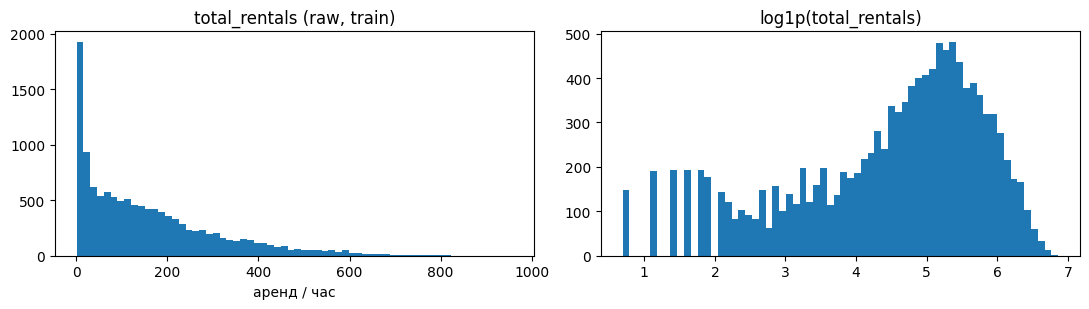

In [5]:
import matplotlib.pyplot as plt

# EDA на train: val/test держим нетронутыми, чтобы описательные наблюдения не подсматривали под отложенные данные.
print("train: mean=%.2f  median=%.0f  max=%d  нулей=%.1f%%  skew=%.2f"
      % (y_train.mean(), y_train.median(), y_train.max(), (y_train == 0).mean() * 100, y_train.skew()))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(y_train, bins=64); ax[0].set_title("total_rentals (raw, train)"); ax[0].set_xlabel("аренд / час")
ax[1].hist(np.log1p(y_train), bins=64); ax[1].set_title("log1p(total_rentals)")
plt.tight_layout(); plt.show()

### Pipeline

Представление признаков — под линейную модель, внутри `ColumnTransformer` (обёртка над `hourly_total`, не новый датасет):

- `hour_of_day`, `month`, `day_of_week` → **cyclic (sin/cos)**, иначе 23:00 и 00:00 «далеко»;
- числовые (`conditions` ordinal, погода, `days_since_launch`) → **StandardScaler**;
- бинарные (`is_weekend`, `is_holiday`) → passthrough.

`make_linear(estimator)` собирает любую линейную модель поверх этого препроцессора; `log_target` оборачивает таргет в log1p/expm1. Обучаемые трансформации фитятся только на train-фолде — утечки нет.

In [6]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler


def cyclic(period):
    """sin/cos-кодирование циклического признака с заданным периодом."""
    return FunctionTransformer(
        lambda x, p=period: np.column_stack([np.sin(2 * np.pi * x / p), np.cos(2 * np.pi * x / p)]),
        feature_names_out="one-to-one",
    )


preprocess = ColumnTransformer([
    ("hour",  cyclic(24), ["hour_of_day"]),
    ("month", cyclic(12), ["month"]),
    ("dow",   cyclic(7),  ["day_of_week"]),
    ("num",   StandardScaler(), ["conditions", "temperature_c", "perceived_temperature_c",
                                 "humidity", "windspeed_kmh", "days_since_launch"]),
    ("bin",   "passthrough", ["is_weekend", "is_holiday"]),
])


def make_linear(estimator, log_target=False):
    """Линейная модель поверх preprocess; log_target=True оборачивает таргет в log1p/expm1."""
    pipe = Pipeline([("pre", preprocess), ("model", estimator)])
    if log_target:
        return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
    return pipe

### Обучение и метрики

Набор: **MAE** (интерпретируемо — «промах на N аренд/час»), **RMSE** (штрафует крупные промахи),
**R²** (доля объяснённой дисперсии), **RMSE/MAE** (диагностика хвоста: ≈1 — однородно, >>1 — есть пики).
Baseline — `LinearRegression`. Обучаем на **train**, меряем на **validation** (test держим до финала).
Сравнение — с наивным baseline (среднее train). Прогноз клипуем снизу нулём.

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2_score(y_true, y_pred), "RMSE/MAE": rmse / mae}


baseline = make_linear(LinearRegression())   # raw-таргет (обоснование ниже)
baseline.fit(X_train, y_train)
val_pred = np.clip(baseline.predict(X_val), 0, None)

results = pd.DataFrame({
    "LinearRegression (val)": evaluate(y_val, val_pred),
    "mean-baseline":          evaluate(y_val, np.full(len(y_val), y_train.mean())),
}).T
results.round(3)

,MAE,RMSE,R2,RMSE/MAE
LinearRegression (val),138.953,174.53,0.389,1.256
mean-baseline,194.135,253.97,-0.294,1.308


### Лог-таргет vs raw

Таргет скошен → стандартная гипотеза попробовать `log1p` (множительный рост → аддитивный). Проверяем: меняем только таргет, модель и сплит фиксированы.

In [8]:
rows = {}
for name, log in [("raw target", False), ("log1p target", True)]:
    m = make_linear(LinearRegression(), log_target=log)
    m.fit(X_train, y_train)
    p = np.clip(m.predict(X_val), 0, None)
    rows[name] = evaluate(y_val, p)
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
raw target,138.953,174.530,0.389,1.256
log1p target,175.852,259.854,-0.355,1.478


**Вывод:** raw уверенно лучше — R²≈0.39 против log1p <0 → **остаёмся на raw**. Слабость линейной модели здесь — нелинейность суточной кривой, а не скошенность; лог её только сильнее размазывает.

### Разрезы ошибок (validation)

Глобальная MAE прячет узкие места. Смотрим по часам суток: где именно линейная модель промахивается (пики vs провал).

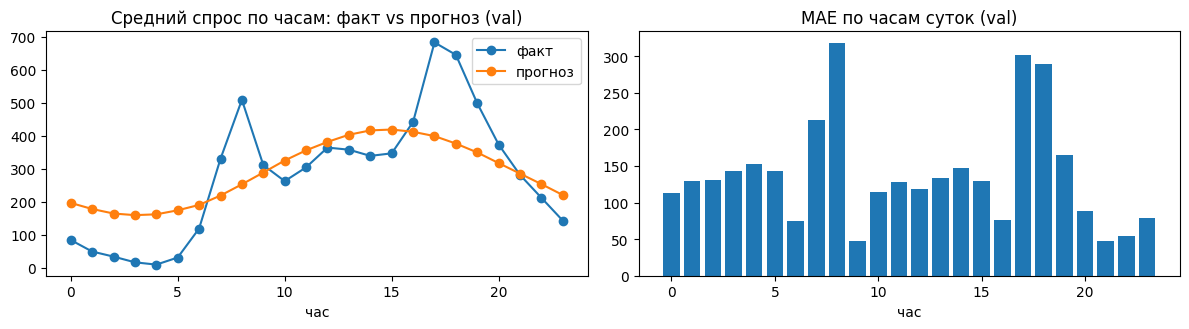

MAE по часам (худшие):
hour_of_day
8     317.9
17    301.0
18    289.0
7     212.3


In [9]:
val_eval = val.assign(pred=val_pred, abs_err=np.abs(y_val.values - val_pred))

by_hour = val_eval.groupby("hour_of_day").agg(
    MAE=("abs_err", "mean"), факт=(TARGET, "mean"), прогноз=("pred", "mean"))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].plot(by_hour.index, by_hour["факт"], marker="o", label="факт")
ax[0].plot(by_hour.index, by_hour["прогноз"], marker="o", label="прогноз")
ax[0].set_title("Средний спрос по часам: факт vs прогноз (val)"); ax[0].set_xlabel("час"); ax[0].legend()
ax[1].bar(by_hour.index, by_hour["MAE"])
ax[1].set_title("MAE по часам суток (val)"); ax[1].set_xlabel("час")
plt.tight_layout(); plt.show()

print("MAE по часам (худшие):")
print(by_hour["MAE"].sort_values(ascending=False).head(4).round(1).to_string())

## Выводы baseline

---

- **Линейная модель уверенно бьёт наивный прогноз** (val R²≈0.39 против отрицательного у «всегда среднее»; MAE ~139 против ~194): она ловит час, сезон, тренд и погоду.
- **Но есть систематический промах.** RMSE/MAE ≈ 1.26 говорит о тяжёлом хвосте ошибок: модель недооценивает дневные пики (8:00 и 17–18:00) и переоценивает ночной провал (в 3:00 предсказывает ~160 при факте ~17). Суточная кривая слишком резкая для пары sin/cos — это нелинейность и взаимодействия (час × сезон, час × погода).
- **Лог-таргет** проигрывает raw по всем метрикам → остаёмся на raw.
- **Test не трогали** — посчитаем один раз, после выбора модели.

Дальше — «Улучшения»: по одному изменению за раунд, сравнение на validation.

## Улучшения

---

Каждый шаг — **одна вещь за раунд**, сравнение на **validation** (test не трогаем). Порядок «просто → сложнее»; усложняем только если оправдано результатом.

### #1. Регуляризация: Ridge

При **n ≫ p** (~12k строк train против ~16 признаков после cyclic) регуляризации нечего стягивать → ожидаем no-op. Быстрая проверка на validation:

In [10]:
rows = {}
for name, est in [("LinearRegression", LinearRegression()),
                  ("Ridge(alpha=1)",   Ridge(alpha=1.0)),
                  ("Ridge(alpha=10)",  Ridge(alpha=10.0))]:
    m = make_linear(est)
    m.fit(X_train, y_train)
    rows[name] = evaluate(y_val, np.clip(m.predict(X_val), 0, None))
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
LinearRegression,138.953,174.530,0.389,1.256
Ridge(alpha=1),138.957,174.534,0.389,1.256
Ridge(alpha=10),138.987,174.575,0.388,1.256


Практически идентично даже при alpha=10 (отличия в 4-м знаке) → при **n ≫ p** регуляризации нечего стягивать, baseline `LinearRegression` остаётся. Реальная слабость — недооценка пиков и переоценка провала (нелинейность) → дальше деревья: **#3 `RandomForestRegressor`**, **#4 `HistGradientBoostingRegressor`**.

### #2. Кодирование `conditions`: ординал vs one-hot

Ординал (0..3 + scaler) навязывает линейной модели **равный шаг** между состояниями погоды
(clear→clouds = light_rain→heavy_rain). One-hot снимает это допущение — свой коэффициент на каждое состояние.
Проверяем, оправдан ли он. (`heavy_rain` редок: всего 3 часа на весь датасет.)

In [11]:
# Два варианта препроцессора, отличаются только обработкой conditions.
WEATHER_NUM = ["temperature_c", "perceived_temperature_c", "humidity", "windspeed_kmh", "days_since_launch"]
common = [
    ("hour",  cyclic(24), ["hour_of_day"]),
    ("month", cyclic(12), ["month"]),
    ("dow",   cyclic(7),  ["day_of_week"]),
    ("bin",   "passthrough", ["is_weekend", "is_holiday"]),
]


def preprocess_conditions(mode):
    if mode == "ordinal":
        steps = common + [("num", StandardScaler(), WEATHER_NUM + ["conditions"])]
    else:  # one-hot
        steps = common + [("num", StandardScaler(), WEATHER_NUM),
                          ("cond", OneHotEncoder(handle_unknown="ignore"), ["conditions"])]
    return ColumnTransformer(steps)


rows = {}
for mode in ["ordinal", "one-hot"]:
    m = Pipeline([("pre", preprocess_conditions(mode)), ("model", LinearRegression())])
    m.fit(X_train, y_train)
    rows[f"conditions = {mode}"] = evaluate(y_val, np.clip(m.predict(X_val), 0, None))
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
conditions = ordinal,138.953,174.530,0.389,1.256
conditions = one-hot,138.952,174.264,0.391,1.254


**Вывод:** one-hot даёт **+0.002 R²** — в пределах шума: погода слабый признак на фоне часа/сезона,
а допущение равного шага здесь почти выполняется. Колонка `heavy_rain` обучается на 3 редких часах —
мёртвый груз. → оставляем **ординал** (проще, по качеству эквивалентно). Для деревьев (#3/#4) кодирование не важно — им ординал ок.

### #3. Нелинейность и взаимодействия: RandomForest

Baseline ловит общий уровень, но промахивается по форме суток (пики и ночной провал) — линейной модели не хватает нелинейности и взаимодействий (`час × сезон`, `час × погода`). Дерево берёт их даром. Меняем **только модель**, фичи и split — те же. Препроцессинг дереву не нужен: `ColumnTransformer` с cyclic/scaling нужен был линейной модели, а RandomForest работает прямо на целочисленных признаках.

In [12]:
from sklearn.ensemble import RandomForestRegressor

# Деревьям ColumnTransformer не нужен: raw integers, RF сам строит взаимодействия.
rf = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rf_pred = np.clip(rf.predict(X_val), 0, None)

rows = {
    "LinearRegression (baseline)": evaluate(y_val, np.clip(baseline.predict(X_val), 0, None)),
    "RandomForest":                evaluate(y_val, rf_pred),
}
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
LinearRegression (baseline),138.953,174.530,0.389,1.256
RandomForest,49.142,79.367,0.874,1.615


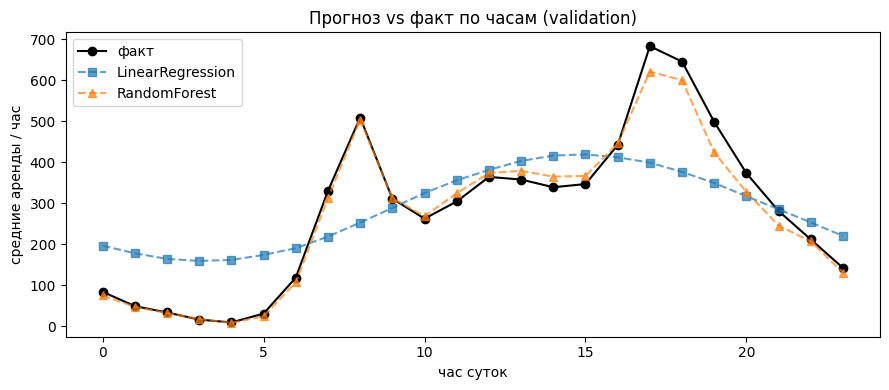

In [13]:
# Профиль по часам: ловит ли RF утренний и вечерний пик, которые baseline недооценивал?
by_hour = (val.assign(LR=np.clip(baseline.predict(X_val), 0, None), RF=rf_pred)
              .groupby("hour_of_day")[[TARGET, "LR", "RF"]].mean())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(by_hour.index, by_hour[TARGET], "o-", color="black", label="факт")
ax.plot(by_hour.index, by_hour["LR"], "s--", alpha=0.7, label="LinearRegression")
ax.plot(by_hour.index, by_hour["RF"], "^--", alpha=0.7, label="RandomForest")
ax.set_xlabel("час суток")
ax.set_ylabel("средние аренды / час")
ax.set_title("Прогноз vs факт по часам (validation)")
ax.legend()
plt.tight_layout(); plt.show()

**Вывод:** RandomForest даёт крупный скачок — ровно на той слабости, что показал baseline.

- **R² 0.39 → 0.87, MAE ~139 → ~49, RMSE ~175 → ~80** (validation), причём без тюнинга, на дефолтных гиперпараметрах.
- На графике видно: утренний (8:00) и вечерний (17–18:00) пики, которые линейная модель срезала, RF восстанавливает (8:00 — факт ~509, было ~253, стало ~504). Ночной провал больше не переоценивает (3:00 — факт ~17, было ~160, стало ~18).
- `RMSE/MAE` вырос (1.26 → 1.61): средняя ошибка упала сильнее пиковой. Остаток ошибки теперь в редких всплесках, а не в систематическом промахе по форме суток.
- Важность признаков: доминирует `hour_of_day` (≈0.60), за ним тренд `days_since_launch` и температура — согласуется с EDA.

Следующий шаг — **#4 `HistGradientBoosting`** (бустинг): строит деревья последовательно, исправляя ошибки, обычно ещё точнее.

### #4. Бустинг: HistGradientBoosting

RandomForest усредняет независимые деревья; **бустинг** строит их последовательно, каждое исправляет
ошибки предыдущих — обычно точнее на табличных данных. Берём `HistGradientBoostingRegressor`
(histogram-based, то же семейство, что XGBoost/LightGBM): он **нативен в sklearn** и не тянет внешних
зависимостей. XGBoost дал бы тот же класс модели, но на macOS требует системный OpenMP (`libomp`) —
лишний блокер ради эквивалентного результата. Меняем только модель; деревьям препроцессинг не нужен.

In [14]:
from sklearn.ensemble import HistGradientBoostingRegressor

# Деревьям препроцессинг не нужен — raw integers. Дефолтные гиперпараметры, без тюнинга.
hgb = HistGradientBoostingRegressor(random_state=42)
hgb.fit(X_train, y_train)
hgb_pred = np.clip(hgb.predict(X_val), 0, None)

rows = {
    "LinearRegression":     evaluate(y_val, np.clip(baseline.predict(X_val), 0, None)),
    "RandomForest":         evaluate(y_val, rf_pred),
    "HistGradientBoosting": evaluate(y_val, hgb_pred),
}
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
LinearRegression,138.953,174.530,0.389,1.256
RandomForest,49.142,79.367,0.874,1.615
HistGradientBoosting,50.428,73.390,0.892,1.455


**Вывод:** HistGradientBoosting слегка обходит RF на validation — **R² 0.874 → 0.892**, RMSE 79.4 → 73.4. `RMSE/MAE` снизился (1.61 → 1.45): бустинг выровнял ошибку, хвост на трудных часах стал короче. MAE почти не изменился (~49 → ~50). Больше итераций (500) делают хуже (переобучение) — дефолт лучше. → это **выбранная модель**, отбор на validation завершён.

### #5. Feature-ablation: убрать `perceived_temperature_c`?

Модель выбрана (HGB) — проверяем, можно ли упростить её фичи. [exploration_weather](exploration_weather.ipynb) показал corr **0.99**
между `temperature_c` и `perceived_temperature_c` → выглядит избыточной. Но по корреляции «на глаз» решать
нельзя — убираем фичу и мерим на validation (модель/сплит фиксированы). Для линейной коллинеарность
теоретически вредна, для деревьев — нет.

In [15]:
# Убираем perceived_temperature_c? corr 0.99 с temperature_c (см. exploration_weather) — выглядит избыточной.
FEATURES_REDUCED = [f for f in FEATURES if f != "perceived_temperature_c"]

# для линейной — препроцессор без perceived (остальное как в baseline)
preprocess_reduced = ColumnTransformer([
    ("hour",  cyclic(24), ["hour_of_day"]),
    ("month", cyclic(12), ["month"]),
    ("dow",   cyclic(7),  ["day_of_week"]),
    ("num",   StandardScaler(), ["conditions", "temperature_c", "humidity", "windspeed_kmh", "days_since_launch"]),
    ("bin",   "passthrough", ["is_weekend", "is_holiday"]),
])

rows = {}
for tag, pre in [("full", preprocess), ("без perceived", preprocess_reduced)]:
    m = Pipeline([("pre", pre), ("model", LinearRegression())]).fit(X_train, y_train)
    rows[f"LinearRegression ({tag})"] = evaluate(y_val, np.clip(m.predict(X_val), 0, None))
for tag, feats in [("full", FEATURES), ("без perceived", FEATURES_REDUCED)]:
    m = HistGradientBoostingRegressor(random_state=42).fit(train[feats], y_train)
    rows[f"HistGB ({tag})"] = evaluate(y_val, np.clip(m.predict(val[feats]), 0, None))
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
LinearRegression (full),138.953,174.530,0.389,1.256
LinearRegression (без perceived),139.357,174.626,0.388,1.253
HistGB (full),50.428,73.390,0.892,1.455
HistGB (без perceived),53.780,77.597,0.879,1.443


**Вывод — `perceived_temperature_c` оставляем.** Корреляция 0.99 ввела в заблуждение. Для линейной модели её удаление почти нейтрально (это коллинеарный дубль, предсказания те же: R² 0.389 → 0.388). Но у выбранной HGB удаление роняет **R² 0.892 → 0.879** (RMSE 73.4 → 77.6). Те ~1% дисперсии, что не совпадают с `temperature_c` — это «ощущаемая» поправка (ветер, влажность; разница до ~13°C), и дерево из неё извлекает сигнал. Поэтому фичу **не трогаем**. Урок: избыточность решает эксперимент (ablation), а не корреляция — как и с праздниками.

## Проверка устойчивости: time-series CV

---

Отбор выше — на **одном** фолде валидации (лето 2012), сезонно узком. Прежде чем идти на test, проверяем
устойчивость выбора: 5-фолдовый `TimeSeriesSplit` на train+val (test держим отдельно) — обучаем на прошлом,
меряем на следующем окне, усредняем по фолдам. Это проверка надёжности, а не новый тюнинг.

In [16]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate

# TS-CV на train+val (test держим отдельно). Строки уже отсортированы по времени → расширяющееся окно.
dev = ds[ds["datetime_hourly"] < cut2]
X_dev, y_dev = dev[FEATURES], dev[TARGET]

tscv = TimeSeriesSplit(n_splits=5)
scoring = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"}
models = {
    "LinearRegression":     make_linear(LinearRegression()),
    "RandomForest":         RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
}

rows = {}
for name, est in models.items():
    cv = cross_validate(est, X_dev, y_dev, cv=tscv, scoring=scoring)
    rows[name] = {"MAE": -cv["test_MAE"].mean(), "RMSE": -cv["test_RMSE"].mean(),
                  "R2 (mean)": cv["test_R2"].mean(), "R2 (std)": cv["test_R2"].std()}
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2 (mean),R2 (std)
LinearRegression,108.704,141.182,0.264,0.130
RandomForest,51.931,79.024,0.760,0.089
HistGradientBoosting,50.062,74.111,0.777,0.139


**Вывод:** выбор устойчив. В среднем по 5 фолдам — **HGB R² ≈ 0.78, RF ≈ 0.76, LR ≈ 0.26**: порядок тот же, что на одиночной валидации, HGB по-прежнему чуть впереди (и по MAE/RMSE).

Но важнее другое: **разброс между фолдами большой** (std R²: RF 0.09, HGB 0.14 — у HGB есть слабый ранний фолд ~0.52, где мало данных), и он **намного больше зазора HGB–RF (~0.02)**. Значит этот зазор **незначим**: на другом окне лидер мог бы поменяться местами — это была бы случайность фолда, а не реальная смена лидера. HGB остаётся защитимым выбором, RF — близкая и чуть более стабильная альтернатива. Деревья во всех фолдах сильно лучше линейной.

## Финал: оценка на test

---

Отбор моделей завершён — на validation выиграл **HistGradientBoosting**. Теперь **единственный** прогон
на held-out **test** (поздний 2012, осень/зима). Это честная оценка обобщения; больше решений по test не принимаем.

In [17]:
# Единственный прогон на test: модели обучены на train, прогноз на held-out test.
rows = {
    "LinearRegression":     evaluate(y_test, np.clip(baseline.predict(X_test), 0, None)),
    "RandomForest":         evaluate(y_test, np.clip(rf.predict(X_test), 0, None)),
    "HistGradientBoosting": evaluate(y_test, np.clip(hgb.predict(X_test), 0, None)),
}
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
LinearRegression,123.587,165.257,0.410,1.337
RandomForest,53.130,80.671,0.859,1.518
HistGradientBoosting,59.245,85.804,0.841,1.448


**Вывод (test):**

- **HistGradientBoosting на test: R² ≈ 0.84, MAE ≈ 59, RMSE ≈ 86** — уверенно объясняет почасовой спрос (наивный прогноз дал бы R²≈0).
- **Порядок RF/HGB на test перевернулся:** на validation впереди был HGB, на test чуть впереди RF (0.859 против 0.841). Разница ~0.02 — это как раз слабость одного окна (validation = лето, test = зима). Перевыбирать модель по test нельзя (это утечка) — оставляем HGB, выбранный по протоколу. Лишний довод в пользу TS-CV.
- Линейный baseline на test чуть лучше, чем на validation (R² 0.41), но всё равно далеко позади деревьев.

В Dagster берём `Pipeline` выбранной модели; в проде — дообучать на всех данных.